In [43]:
!pip install category_encoders feature-engine

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    PowerTransformer,
    OrdinalEncoder
)

import category_encoders as ce

from feature_engine.creation import MathFeatures

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [45]:
df = pd.read_csv('/content/sales_data.csv')

df.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating
0,1001,2024-04-12,Karachi,Furniture,Cash,83.43,6,0.05,4.0,4.4
1,1002,2025-03-11,Islamabad,Clothing,Bank Transfer,31.27,4,0.14,3.0,3.6
2,1003,2024-12-14,Quetta,Electronics,Cash,162.15,2,0.37,7.0,3.4
3,1004,2024-09-27,Karachi,Clothing,Cash,159.39,2,0.09,8.0,4.1
4,1005,2024-04-16,Peshawar,Toys,Wallet,114.08,9,0.15,NaN,3.8


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   order_date        500 non-null    object 
 2   city              500 non-null    object 
 3   product_category  500 non-null    object 
 4   payment_method    500 non-null    object 
 5   unit_price        500 non-null    float64
 6   quantity          500 non-null    int64  
 7   discount_pct      500 non-null    float64
 8   delivery_days     490 non-null    float64
 9   customer_rating   485 non-null    float64
dtypes: float64(4), int64(2), object(4)
memory usage: 39.2+ KB


In [47]:
df.describe()

,order_id,unit_price,quantity,discount_pct,delivery_days,customer_rating
count,500.000000,500.00000,500.000000,500.000000,490.000000,485.000000
mean,1250.500000,97.73364,4.914000,0.200880,4.932653,3.942887
std,144.481833,63.13275,2.552574,0.114545,2.031841,0.727312
min,1001.000000,8.93000,1.000000,0.000000,1.000000,1.700000
25%,1125.750000,51.48500,3.000000,0.100000,4.000000,3.500000
50%,1250.500000,82.84000,5.000000,0.210000,5.000000,3.900000
75%,1375.250000,126.85000,7.000000,0.300000,6.000000,4.500000
max,1500.000000,350.83000,9.000000,0.400000,11.000000,5.000000


In [48]:
df.shape

(500, 10)

In [49]:
df.columns

Index(['order_id', 'order_date', 'city', 'product_category', 'payment_method',
       'unit_price', 'quantity', 'discount_pct', 'delivery_days',
       'customer_rating'],
      dtype='object')

In [50]:
df.isnull().sum()

,0
order_id,0
order_date,0
city,0
product_category,0
payment_method,0
unit_price,0
quantity,0
discount_pct,0
delivery_days,10
customer_rating,15


In [51]:
df.fillna(df.median(numeric_only=True), inplace=True)

### Feature Engineering: Calculate 'Sales' Column

To resolve the `KeyError: 'Sales'`, I will create a new 'Sales' column by multiplying `unit_price` by `quantity` and then applying the `discount_pct`. This new column will serve as the target variable for subsequent encoding steps.

In [52]:
# Calculate the 'Sales' column
df['Sales'] = df['unit_price'] * df['quantity'] * (1 - df['discount_pct'])

# Display the first few rows with the new 'Sales' column
display(df.head())

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,1001,2024-04-12,Karachi,Furniture,Cash,83.43,6,0.05,4.0,4.4,475.5510
1,1002,2025-03-11,Islamabad,Clothing,Bank Transfer,31.27,4,0.14,3.0,3.6,107.5688
2,1003,2024-12-14,Quetta,Electronics,Cash,162.15,2,0.37,7.0,3.4,204.3090
3,1004,2024-09-27,Karachi,Clothing,Cash,159.39,2,0.09,8.0,4.1,290.0898
4,1005,2024-04-16,Peshawar,Toys,Wallet,114.08,9,0.15,5.0,3.8,872.7120


In [53]:
categorical_columns = df.select_dtypes(include=['object']).columns

numerical_columns = df.select_dtypes(include=np.number).columns

print("Categorical Columns:")
print(categorical_columns)

print()

print("Numerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['order_date', 'city', 'product_category', 'payment_method'], dtype='object')

Numerical Columns:
Index(['order_id', 'unit_price', 'quantity', 'discount_pct', 'delivery_days',
       'customer_rating', 'Sales'],
      dtype='object')


In [54]:
df_ohe = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

df_ohe.head()

,order_id,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales,order_date_2024-01-04,order_date_2024-01-05,order_date_2024-01-06,...,city_Multan,city_Peshawar,city_Quetta,product_category_Electronics,product_category_Furniture,product_category_Grocery,product_category_Toys,payment_method_Cash,payment_method_Credit Card,payment_method_Wallet
0,1001,83.43,6,0.05,4.0,4.4,475.5510,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,1002,31.27,4,0.14,3.0,3.6,107.5688,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1003,162.15,2,0.37,7.0,3.4,204.3090,False,False,False,...,False,False,True,True,False,False,False,True,False,False
3,1004,159.39,2,0.09,8.0,4.1,290.0898,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,1005,114.08,9,0.15,5.0,3.8,872.7120,False,False,False,...,False,True,False,False,False,False,True,False,False,True


In [55]:
encoder = OrdinalEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[[col]])

df.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,1001,56.0,1.0,2.0,1.0,83.43,6,0.05,4.0,4.4,475.5510
1,1002,258.0,0.0,0.0,0.0,31.27,4,0.14,3.0,3.6,107.5688
2,1003,210.0,5.0,1.0,1.0,162.15,2,0.37,7.0,3.4,204.3090
3,1004,166.0,1.0,0.0,1.0,159.39,2,0.09,8.0,4.1,290.0898
4,1005,59.0,4.0,4.0,3.0,114.08,9,0.15,5.0,3.8,872.7120


In [56]:
from category_encoders import TargetEncoder

In [57]:
target = "Sales"

In [58]:
encoder = TargetEncoder()

# Defensive check: ensure 'Sales' column exists. Re-calculate if missing.
if 'Sales' not in df.columns:
    df['Sales'] = df['unit_price'] * df['quantity'] * (1 - df['discount_pct'])
    print("Warning: 'Sales' column was missing and has been re-calculated.")

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col], df[target])

In [59]:
scaler = StandardScaler()

df_standard = df.copy()

df_standard[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df_standard.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,-1.728590,56.0,1.0,2.0,1.0,-0.226791,0.425879,-1.318525,-0.464818,0.640565,0.268885
1,-1.721662,258.0,0.0,0.0,0.0,-1.053814,-0.358429,-0.532024,-0.962482,-0.477349,-0.793300
2,-1.714734,210.0,5.0,1.0,1.0,1.021354,-1.142736,1.477923,1.028173,-0.756828,-0.514058
3,-1.707806,166.0,1.0,0.0,1.0,0.977593,-1.142736,-0.968969,1.525837,0.221347,-0.266451
4,-1.700877,59.0,4.0,4.0,3.0,0.259180,1.602340,-0.444635,0.032846,-0.197871,1.415296


In [60]:
minmax = MinMaxScaler()

df_minmax = df.copy()

df_minmax[numerical_columns] = minmax.fit_transform(df[numerical_columns])

df_minmax.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,0.000000,56.0,1.0,2.0,1.0,0.217900,0.625,0.125,0.3,0.818182,0.214581
1,0.002004,258.0,0.0,0.0,0.0,0.065341,0.375,0.350,0.2,0.575758,0.044879
2,0.004008,210.0,5.0,1.0,1.0,0.448143,0.125,0.925,0.6,0.515152,0.089492
3,0.006012,166.0,1.0,0.0,1.0,0.440070,0.125,0.225,0.7,0.727273,0.129052
4,0.008016,59.0,4.0,4.0,3.0,0.307546,1.000,0.375,0.4,0.636364,0.397739


In [61]:
robust = RobustScaler()

df_robust = df.copy()

df_robust[numerical_columns] = robust.fit_transform(df[numerical_columns])

df_robust.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,-1.000000,56.0,1.0,2.0,1.0,0.007829,0.25,-0.80,-0.5,0.5,0.496324
1,-0.995992,258.0,0.0,0.0,0.0,-0.684270,-0.25,-0.35,-1.0,-0.3,-0.446535
2,-0.991984,210.0,5.0,1.0,1.0,1.052345,-0.75,0.80,1.0,-0.5,-0.198663
3,-0.987976,166.0,1.0,0.0,1.0,1.015723,-0.75,-0.60,1.5,0.2,0.021128
4,-0.983968,59.0,4.0,4.0,3.0,0.414516,1.00,-0.30,0.0,-0.1,1.513945


In [62]:
df_log = df.copy()

for col in numerical_columns:
    if (df_log[col] >= 0).all():
        df_log[col] = np.log1p(df_log[col])

df_log.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,6.909753,56.0,1.0,2.0,1.0,4.435923,1.945910,0.048790,1.609438,1.686399,6.166575
1,6.910751,258.0,0.0,0.0,0.0,3.474138,1.609438,0.131028,1.386294,1.526056,4.687384
2,6.911747,210.0,5.0,1.0,1.0,5.094670,1.098612,0.314811,2.079442,1.481605,5.324516
3,6.912743,166.0,1.0,0.0,1.0,5.077608,1.098612,0.086178,2.197225,1.629241,5.673632
4,6.913737,59.0,4.0,4.0,3.0,4.745628,2.302585,0.139762,1.791759,1.568616,6.772751


In [63]:
power = PowerTransformer(method='box-cox')

positive_cols = []

for col in numerical_columns:
    if (df[col] > 0).all():
        positive_cols.append(col)

df_boxcox = df.copy()

df_boxcox[positive_cols] = power.fit_transform(df_boxcox[positive_cols])

df_boxcox.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales
0,-1.758916,56.0,1.0,2.0,1.0,0.006549,0.487500,0.05,-0.404468,0.618682,0.624472
1,-1.751601,258.0,0.0,0.0,0.0,-1.305725,-0.262198,0.14,-0.950733,-0.533015,-0.921461
2,-1.744289,210.0,5.0,1.0,1.0,1.076541,-1.150687,0.37,1.022009,-0.797844,-0.289863
3,-1.736978,166.0,1.0,0.0,1.0,1.046817,-1.150687,0.09,1.451032,0.169859,0.077658
4,-1.729669,59.0,4.0,4.0,3.0,0.490288,1.474381,0.15,0.099867,-0.258767,1.344855


In [64]:
df["Feature_Interaction"] = df[numerical_columns[0]] * df[numerical_columns[1]]

df.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales,Feature_Interaction
0,1001,56.0,1.0,2.0,1.0,83.43,6,0.05,4.0,4.4,475.5510,83513.43
1,1002,258.0,0.0,0.0,0.0,31.27,4,0.14,3.0,3.6,107.5688,31332.54
2,1003,210.0,5.0,1.0,1.0,162.15,2,0.37,7.0,3.4,204.3090,162636.45
3,1004,166.0,1.0,0.0,1.0,159.39,2,0.09,8.0,4.1,290.0898,160027.56
4,1005,59.0,4.0,4.0,3.0,114.08,9,0.15,5.0,3.8,872.7120,114650.40


In [65]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [66]:
df["Year"] = df["order_date"].dt.year

df["Month"] = df["order_date"].dt.month

df["Day"] = df["order_date"].dt.day

df["Weekday"] = df["order_date"].dt.day_name()

df.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales,Feature_Interaction,Year,Month,Day,Weekday
0,1001,1970-01-01 00:00:00.000000056,1.0,2.0,1.0,83.43,6,0.05,4.0,4.4,475.5510,83513.43,1970,1,1,Thursday
1,1002,1970-01-01 00:00:00.000000258,0.0,0.0,0.0,31.27,4,0.14,3.0,3.6,107.5688,31332.54,1970,1,1,Thursday
2,1003,1970-01-01 00:00:00.000000210,5.0,1.0,1.0,162.15,2,0.37,7.0,3.4,204.3090,162636.45,1970,1,1,Thursday
3,1004,1970-01-01 00:00:00.000000166,1.0,0.0,1.0,159.39,2,0.09,8.0,4.1,290.0898,160027.56,1970,1,1,Thursday
4,1005,1970-01-01 00:00:00.000000059,4.0,4.0,3.0,114.08,9,0.15,5.0,3.8,872.7120,114650.40,1970,1,1,Thursday


In [67]:
df["Total_Value"] = df[numerical_columns[0]] + df[numerical_columns[1]]

df.head()

,order_id,order_date,city,product_category,payment_method,unit_price,quantity,discount_pct,delivery_days,customer_rating,Sales,Feature_Interaction,Year,Month,Day,Weekday,Total_Value
0,1001,1970-01-01 00:00:00.000000056,1.0,2.0,1.0,83.43,6,0.05,4.0,4.4,475.5510,83513.43,1970,1,1,Thursday,1084.43
1,1002,1970-01-01 00:00:00.000000258,0.0,0.0,0.0,31.27,4,0.14,3.0,3.6,107.5688,31332.54,1970,1,1,Thursday,1033.27
2,1003,1970-01-01 00:00:00.000000210,5.0,1.0,1.0,162.15,2,0.37,7.0,3.4,204.3090,162636.45,1970,1,1,Thursday,1165.15
3,1004,1970-01-01 00:00:00.000000166,1.0,0.0,1.0,159.39,2,0.09,8.0,4.1,290.0898,160027.56,1970,1,1,Thursday,1163.39
4,1005,1970-01-01 00:00:00.000000059,4.0,4.0,3.0,114.08,9,0.15,5.0,3.8,872.7120,114650.40,1970,1,1,Thursday,1119.08


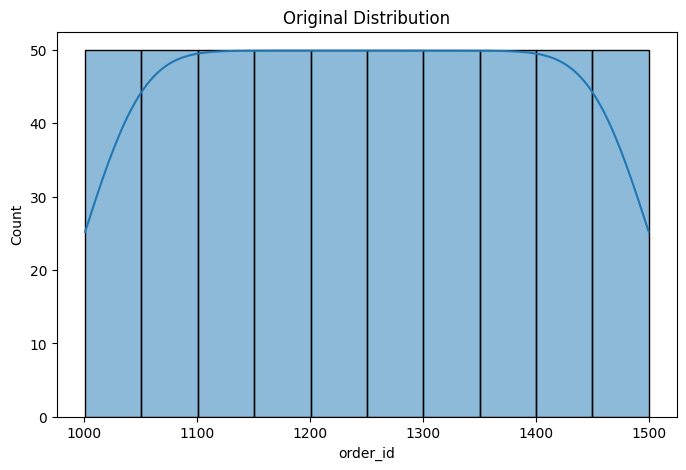

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(df[numerical_columns[0]], kde=True)

plt.title("Original Distribution")

plt.show()

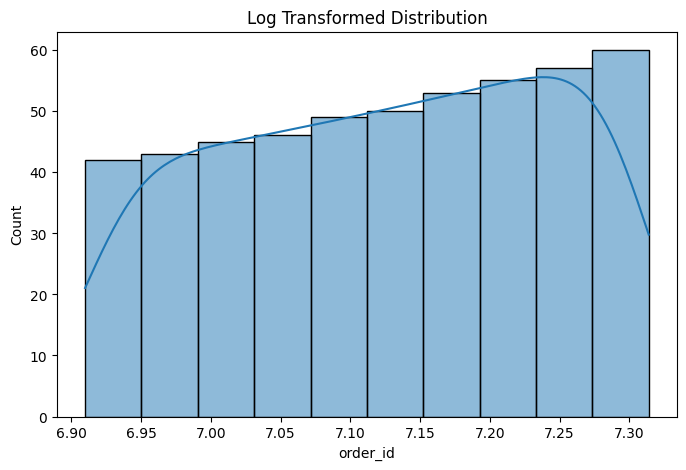

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(df_log[numerical_columns[0]], kde=True)

plt.title("Log Transformed Distribution")

plt.show()

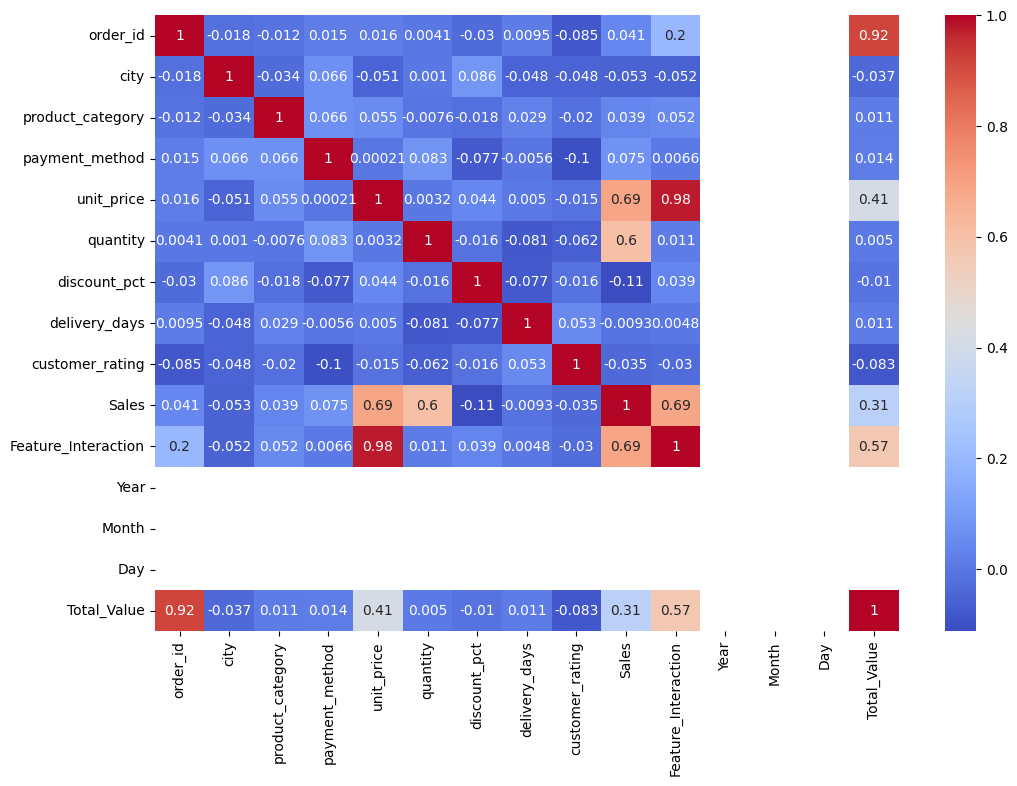

In [70]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [71]:
df.to_csv("feature_engineered_sales_data.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [72]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("standard_scaler", StandardScaler())
])

print(pipeline)

Pipeline(steps=[('standard_scaler', StandardScaler())])
